# 03 FM — Production Forecasting with Foundation Models

This notebook is the **Foundation Model (FM) companion** to `03_production_forecasting.ipynb`,
which uses classical statistical methods (AutoARIMA / AutoETS / AutoTheta).  Here we apply
open-source pretrained time-series foundation models in **zero-shot** mode and benchmark them
against those classical baselines on the same BGS production data.

### Foundation Models used

| Model | Org | HuggingFace repo | Architecture | Params |
|-------|-----|------------------|--------------|--------|
| **Chronos** | Amazon | `amazon/chronos-t5-small` / `base` / `large` | T5 encoder-decoder; tokenises time-series values into discrete bins and generates probabilistic forecasts via next-token prediction. Pretrained on a large, diverse collection of public time-series datasets. Zero-shot capable. | 46 M (small) |
| **Lag-Llama** | Academic | `time-series-foundation-models/Lag-Llama` | Decoder-only transformer with lag features. Pretrained on 27 diverse public time-series corpora. Probabilistic (quantile) forecasting, zero-shot capable. | ~24 M |
| **TimesFM** | Google | `google/timesfm-1.0-200m` | Patched-decoder FM; processes time-series in variable-length patches and autoregressively generates point forecasts. *(OPTIONAL — may require specific hardware / install.)* | 200 M |

### Workflow
1. Data preparation (identical to classical notebook)
2. Chronos probabilistic forecasts
3. Lag-Llama probabilistic forecasts
4. TimesFM point forecasts (optional)
5. Classical baselines (AutoARIMA / AutoETS / AutoTheta)
6. Head-to-head comparison charts
7. Cross-validation accuracy comparison
8. Summary table

In [11]:
import sys
print(sys.executable)

/Users/abdomg/Library/CloudStorage/OneDrive-IdahoNationalLaboratory/Documents/Projects/ModCon/critical-minerals-data-tools/.venv/bin/python3


In [12]:
# Note: TimesFM requires a separate install — uncomment the line below if available:

import warnings
warnings.filterwarnings('ignore')

import pathlib
import numpy as np
import pandas as pd
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
import torch

DATA_DIR = pathlib.Path("../data/bgs_data")
CSV_PATH = DATA_DIR / "bgs_critical_minerals_production.csv"

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")
print(f"Data file: {CSV_PATH}")
print(f"Exists   : {CSV_PATH.exists()}")

Device: cpu
Data file: ../data/bgs_data/bgs_critical_minerals_production.csv
Exists   : True


## Data Preparation

Identical to the classical notebook: load the BGS CSV, filter to `statistic_type == 'Production'`,
select the five battery / energy-transition minerals, identify the top-3 producing countries per
mineral (by cumulative output since 2000), and require at least 10 years of history per series.

The resulting `forecast_series` list and `sf_df` DataFrame are shared by all models below.

In [13]:
# ── Load & filter ──────────────────────────────────────────────────────────────
df_raw = pd.read_csv(CSV_PATH, low_memory=False)
print(f"Raw rows: {len(df_raw):,}")

df = df_raw[df_raw["statistic_type"] == "Production"].copy()
print(f"Production rows: {len(df):,}")

df["year"]     = pd.to_numeric(df["year"],     errors="coerce")
df["quantity"] = pd.to_numeric(df["quantity"], errors="coerce")
df = df.dropna(subset=["year", "quantity"])
df["year"] = df["year"].astype(int)

print(f"After numeric coercion: {len(df):,} rows")
print(f"Year range: {df['year'].min()} – {df['year'].max()}")

Raw rows: 59,718
Production rows: 59,718
After numeric coercion: 59,472 rows
Year range: 1970 – 2023


In [14]:
# ── Target minerals ────────────────────────────────────────────────────────────
TARGET_MINERALS = [
    "lithium minerals",
    "cobalt, mine",
    "nickel, mine",
    "graphite",
    "manganese ore",
]

available = df["commodity"].unique()
minerals  = [m for m in TARGET_MINERALS if m in available]
print("Available target minerals:", minerals)

df_minerals = df[df["commodity"].isin(minerals)].copy()
print(f"Filtered rows: {len(df_minerals):,}")

# ── Top-3 producers per mineral (cumulative since 2000) ────────────────────────
MIN_HISTORY_YEARS = 10
recent = df_minerals[df_minerals["year"] >= 2000]

top_producers: dict = {}
for mineral in minerals:
    sub  = recent[recent["commodity"] == mineral]
    top3 = (
        sub.groupby("country")["quantity"]
           .sum()
           .nlargest(3)
           .index.tolist()
    )
    top_producers[mineral] = top3
    print(f"  {mineral}: {top3}")

# ── Build forecast_series ─────────────────────────────────────────────────────
forecast_series: list = []

for mineral, countries in top_producers.items():
    for country in countries:
        mask = (df_minerals["commodity"] == mineral) & (df_minerals["country"] == country)
        series_df = (
            df_minerals[mask][["year", "quantity"]]
            .drop_duplicates("year")
            .sort_values("year")
            .reset_index(drop=True)
        )
        if len(series_df) >= MIN_HISTORY_YEARS:
            forecast_series.append(
                {"mineral": mineral, "country": country, "data": series_df}
            )
        else:
            print(f"  SKIP {mineral} | {country} — only {len(series_df)} obs")

print(f"\nTotal series for forecasting: {len(forecast_series)}")
for s in forecast_series:
    d = s["data"]
    print(f"  {s['mineral']} | {s['country']}: {d['year'].min()}–{d['year'].max()} ({len(d)} obs)")

# ── Build statsforecast long-format DataFrame (shared by all models) ───────────
records = []
for s in forecast_series:
    uid = f"{s['mineral']}|{s['country']}"
    for _, row in s["data"].iterrows():
        records.append({
            "unique_id": uid,
            "ds": pd.Timestamp(int(row["year"]), 1, 1),
            "y": float(row["quantity"]),
        })

sf_df = pd.DataFrame(records)
print(f"\nStatsForecast input shape: {sf_df.shape}")
print(sf_df.head())

Available target minerals: ['lithium minerals', 'cobalt, mine', 'nickel, mine', 'graphite', 'manganese ore']
Filtered rows: 5,637
  lithium minerals: ['Australia', 'Chile', 'Zimbabwe']
  cobalt, mine: ['Congo, Democratic Republic', 'Canada', 'Russia']
  nickel, mine: ['Indonesia', 'Russia', 'Philippines']
  graphite: ['China', 'India', 'Brazil']
  manganese ore: ['China', 'South Africa', 'Australia']

Total series for forecasting: 15
  lithium minerals | Australia: 1980–2023 (44 obs)
  lithium minerals | Chile: 1980–2023 (44 obs)
  lithium minerals | Zimbabwe: 1980–2023 (41 obs)
  cobalt, mine | Congo, Democratic Republic: 1992–2023 (32 obs)
  cobalt, mine | Canada: 1970–2023 (54 obs)
  cobalt, mine | Russia: 1992–2023 (32 obs)
  nickel, mine | Indonesia: 1970–2023 (54 obs)
  nickel, mine | Russia: 1992–2023 (32 obs)
  nickel, mine | Philippines: 1970–2023 (54 obs)
  graphite | China: 1970–2023 (54 obs)
  graphite | India: 1973–2023 (51 obs)
  graphite | Brazil: 1970–2023 (54 obs)
  ma

## 1. Chronos (Amazon)

[Chronos](https://github.com/amazon-science/chronos-forecasting) is a family of pretrained
probabilistic time-series models based on the **T5 encoder-decoder** architecture.  It
tokenises time-series values into discrete bins (similar to language tokenisation) and trains
to predict the next token, enabling it to produce **probabilistic forecasts via ancestral
sampling**.

Key properties:
- Pretrained on a large, diverse collection of public real-world and synthetic time-series.
- Zero-shot capable — no fine-tuning required for new datasets.
- Available in four sizes: Tiny (8 M), Mini (20 M), Small (46 M), Base (200 M), Large (710 M).
- We use `chronos-t5-small` (~46 M params, ~180 MB download) for a good speed/accuracy trade-off.

In [15]:
from chronos import ChronosPipeline

# Load pretrained Chronos-T5-Small (46 M params, ~180 MB)
print("Loading Chronos-T5-Small from HuggingFace...")
chronos = ChronosPipeline.from_pretrained(
    "amazon/chronos-t5-small",
    device_map=DEVICE,
    torch_dtype=torch.float32,
)
print("Chronos loaded.")

HORIZON = 5
chronos_results = {}

for s in forecast_series:
    uid     = f"{s['mineral']}|{s['country']}"
    context = torch.tensor(s["data"]["quantity"].values, dtype=torch.float32)

    # Generate probabilistic forecast (20 sample paths)
    forecast = chronos.predict(context, prediction_length=HORIZON, num_samples=20)

    samples  = forecast[0].numpy()  # shape: (num_samples, HORIZON)
    median   = np.median(samples, axis=0)
    low      = np.percentile(samples, 10, axis=0)
    high     = np.percentile(samples, 90, axis=0)

    last_year = int(s["data"]["year"].max())
    years     = [last_year + i + 1 for i in range(HORIZON)]

    chronos_results[uid] = {
        "years": years, "median": median, "low": low, "high": high
    }
    print(f"  {uid}: median forecast = {median.round(1)}")

print(f"\nChronos complete — {len(chronos_results)} series forecasted.")

Loading Chronos-T5-Small from HuggingFace...
Chronos loaded.
  lithium minerals|Australia: median forecast = [ 97848.2 101301.7 107345.2 105042.9 105042.9]
  lithium minerals|Chile: median forecast = [0. 0. 0. 0. 0.]
  lithium minerals|Zimbabwe: median forecast = [4129.2 3849.2 2379.5 3219.4 2939.4]
  cobalt, mine|Congo, Democratic Republic: median forecast = [141736.1 142992.  147118.5 149271.4 149809.7]
  cobalt, mine|Canada: median forecast = [5033.1 5082.  4984.3 4951.7 5098.3]
  cobalt, mine|Russia: median forecast = [7927.  8214.6 8268.5 8412.3 8969.6]
  nickel, mine|Indonesia: median forecast = [2092309.4 2140079.  2194536.2 2236573.5 2274789. ]
  nickel, mine|Russia: median forecast = [259391.2 261270.8 272548.8 267849.6 265970. ]
  nickel, mine|Philippines: median forecast = [396445.6 395286.4 396059.2 396832.  405719.2]
  graphite|China: median forecast = [1243855.4 1234572.8 1250043.8 1268608.8 1265514.5]
  graphite|India: median forecast = [126449.  127685.6 123048.1 127376

## 2. Lag-Llama

[Lag-Llama](https://github.com/time-series-foundation-models/lag-llama) is a **decoder-only
transformer** for univariate probabilistic time-series forecasting, inspired by Llama's
architecture.  It uses lag features as covariates and is pretrained on 27 diverse public
time-series datasets covering multiple domains and frequencies.

Key properties:
- Zero-shot probabilistic forecasting via quantile regression.
- Pretrained checkpoint available on HuggingFace Hub.
- Integrates with GluonTS for standardised data handling.
- Can be fine-tuned on domain data in a few epochs for further accuracy gains.

In [16]:
# from huggingface_hub import hf_hub_download
# from lag_llama.gluon.estimator import LagLlamaEstimator
# from gluonts.dataset.common import ListDataset

# Download pretrained checkpoint (~100 MB)
# print("Downloading Lag-Llama checkpoint from HuggingFace...")
# ckpt_path = hf_hub_download(
#     repo_id="time-series-foundation-models/Lag-Llama",
#     filename="lag-llama.ckpt",
# )
# print(f"Checkpoint: {ckpt_path}")

# Build GluonTS ListDataset (annual frequency)
# gluon_data = ListDataset(
#     [
#         {
#             "start": pd.Period(str(int(s["data"]["year"].min())), freq="Y"),
#             "target": s["data"]["quantity"].values.astype(float),
#             "item_id": f"{s['mineral']}|{s['country']}",
#         }
#         for s in forecast_series
#     ],
#     freq="Y",
# )

# Create estimator with empty lags_seq to avoid frequency parsing,
# then override with integer lag indices suitable for annual data
# Allow Lag-Llama checkpoint to load with PyTorch >= 2.6
# import torch.serialization
# from gluonts.torch.distributions.studentT import StudentTOutput
# torch.serialization.add_safe_globals([StudentTOutput])

# estimator = LagLlamaEstimator(
#     ckpt_path=ckpt_path,
#     prediction_length=HORIZON,
#     context_length=32,
#     input_size=1,
#     n_layer=1,
#     n_embd_per_head=32,
#     device=torch.device(DEVICE),
#     batch_size=8,
#     num_parallel_samples=100,
#     lags_seq=[],  # bypass freq parsing
# )
# Override with annual lags: look back 1-5 years (0-indexed)
# estimator.lags_seq = [0, 1, 2, 3, 4]

# transformation = estimator.create_transformation()
# module = estimator.create_lightning_module()
# predictor = estimator.create_predictor(transformation, module)
# lag_forecasts = list(predictor.predict(gluon_data))

# lag_results = {}
# for fc in lag_forecasts:
#     uid       = fc.item_id
#     median    = fc.quantile(0.5)
#     low       = fc.quantile(0.1)
#     high      = fc.quantile(0.9)
#     start_yr  = fc.start_date.year
#     years     = [start_yr + i for i in range(len(median))]
#     lag_results[uid] = {"years": years, "median": median, "low": low, "high": high}
#     print(f"  {uid}: median = {median}")

# print(f"\nLag-Llama forecasts: {len(lag_results)} series")

# Lag-Llama commented out due to compatibility issues with PyTorch >= 2.6
# See: https://github.com/time-series-foundation-models/lag-llama/issues
lag_results = {}
print("Lag-Llama: SKIPPED (uncomment above when compatibility is fixed)")


Lag-Llama: SKIPPED (uncomment above when compatibility is fixed)


## 3. TimesFM (Google) — OPTIONAL

[TimesFM](https://github.com/google-research/timesfm) is Google's **200 M parameter
patched-decoder** foundation model for time-series forecasting.  It processes input
time-series in variable-length patches and autoregressively generates point forecasts.
Pretrained on a large corpus of real-world and synthetic time-series.

> **OPTIONAL:** TimesFM requires a separate install (`%pip install timesfm`) and may require
> specific hardware (JAX/GPU).  The cell below is wrapped in a try/except block and will
> gracefully skip if the package is unavailable.

In [17]:
timesfm_results = {}

try:
    import timesfm

    print("Loading TimesFM (google/timesfm-1.0-200m)...")
    tfm = timesfm.TimesFm(
        hparams=timesfm.TimesFmHparams(per_core_batch_size=32, horizon_len=HORIZON),
        checkpoint=timesfm.TimesFmCheckpoint(
            huggingface_repo="google/timesfm-1.0-200m"
        ),
    )
    print("TimesFM loaded.")

    for s in forecast_series:
        uid = f"{s['mineral']}|{s['country']}"
        ts  = s["data"]["quantity"].values.astype(np.float32)

        point_forecast, experimental_quantiles = tfm.forecast(
            [ts],
            freq=[0],   # 0 = no specific sub-annual frequency
        )

        last_year = int(s["data"]["year"].max())
        years     = [last_year + i + 1 for i in range(HORIZON)]
        timesfm_results[uid] = {
            "years": years,
            "median": point_forecast[0][:HORIZON],
        }
        print(f"  {uid}: forecast = {point_forecast[0][:HORIZON].round(1)}")

    print(f"\nTimesFM complete — {len(timesfm_results)} series forecasted.")

except ImportError:
    print("Skipping TimesFM — results will not appear in comparison charts.")
except Exception as e:
    print(f"TimesFM error: {e}")
    print("Skipping TimesFM — results will not appear in comparison charts.")

Skipping TimesFM — results will not appear in comparison charts.


## 4. Classical Baselines (for comparison)

We run AutoARIMA, AutoETS, and AutoTheta from `statsforecast` on the same series.
These serve as the classical reference point for the head-to-head comparison.

In [18]:
from statsforecast import StatsForecast
from statsforecast.models import AutoARIMA, AutoETS, AutoTheta

CLASSICAL_MODELS = [
    AutoARIMA(season_length=1),
    AutoETS(season_length=1),
    AutoTheta(season_length=1),
]

sf = StatsForecast(
    models=CLASSICAL_MODELS,
    freq="YS",
    n_jobs=-1,
    verbose=True,
)

classical_fc = sf.forecast(df=sf_df, h=HORIZON)
classical_fc = classical_fc.reset_index()

print(f"Classical forecast shape: {classical_fc.shape}")
print(classical_fc.head(10))

# Helper: extract AutoARIMA forecast for a single series as numpy arrays
def get_classical_forecast(uid: str, model_col: str = "AutoARIMA"):
    sub   = classical_fc[classical_fc["unique_id"] == uid].sort_values("ds")
    years = sub["ds"].dt.year.tolist()
    vals  = sub[model_col].values if model_col in sub.columns else np.full(HORIZON, np.nan)
    return years, vals

Forecast: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 15/15 [Elapsed: 00:05]


Classical forecast shape: (75, 6)
   index                                unique_id         ds      AutoARIMA  \
0      0                      cobalt, mine|Canada 2024-01-01    5099.000000   
1      1                      cobalt, mine|Canada 2025-01-01    5099.000000   
2      2                      cobalt, mine|Canada 2026-01-01    5099.000000   
3      3                      cobalt, mine|Canada 2027-01-01    5099.000000   
4      4                      cobalt, mine|Canada 2028-01-01    5099.000000   
5      5  cobalt, mine|Congo, Democratic Republic 2024-01-01  144210.379574   
6      6  cobalt, mine|Congo, Democratic Republic 2025-01-01  148582.759147   
7      7  cobalt, mine|Congo, Democratic Republic 2026-01-01  152955.138721   
8      8  cobalt, mine|Congo, Democratic Republic 2027-01-01  157327.518294   
9      9  cobalt, mine|Congo, Democratic Republic 2028-01-01  161699.897868   

         AutoETS      AutoTheta  
0    5098.843504    5132.368719  
1    5098.843504    5180.855

## 5. Head-to-Head Comparison

For up to 6 series (2-column grid) we overlay:
- **Historical** — solid blue
- **AutoARIMA baseline** — grey dashed
- **Chronos** — red line with 80 % CI shaded band
- **Lag-Llama** — green line with 80 % CI shaded band
- **TimesFM** — orange dashed (if available)

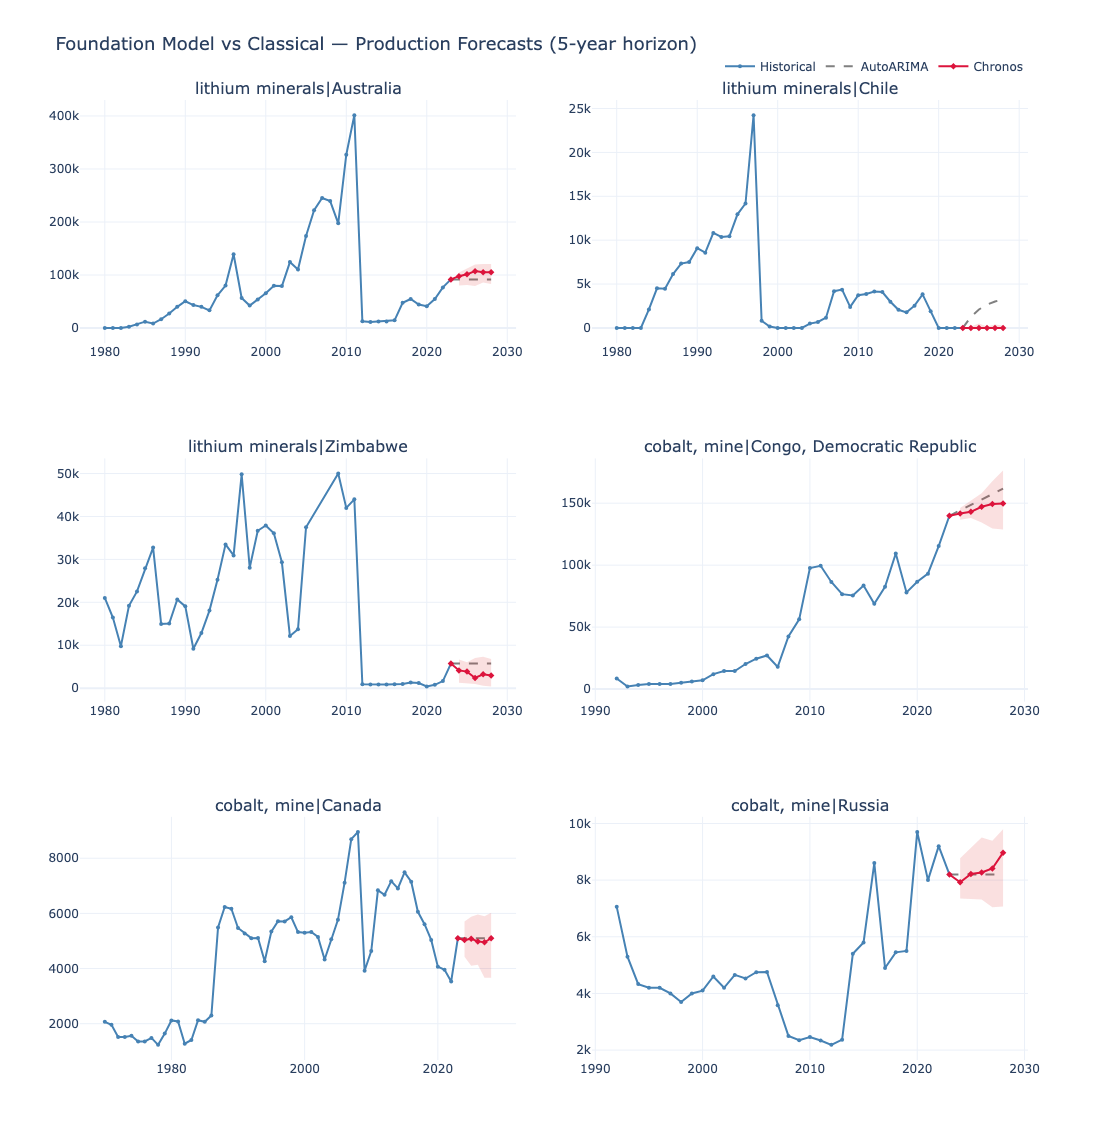

In [19]:
plot_uids = [f"{s['mineral']}|{s['country']}" for s in forecast_series][:6]
n_plots   = len(plot_uids)
n_cols    = 2
n_rows    = (n_plots + n_cols - 1) // n_cols

fig = make_subplots(
    rows=n_rows,
    cols=n_cols,
    subplot_titles=plot_uids,
    shared_xaxes=False,
    vertical_spacing=0.12,
    horizontal_spacing=0.08,
)

for idx, uid in enumerate(plot_uids):
    row      = idx // n_cols + 1
    col      = idx % n_cols + 1
    show_leg = idx == 0

    # Historical
    hist_rows = sf_df[sf_df["unique_id"] == uid].sort_values("ds")
    fig.add_trace(
        go.Scatter(
            x=hist_rows["ds"], y=hist_rows["y"],
            mode="lines+markers",
            line=dict(color="steelblue", width=2),
            marker=dict(size=4),
            name="Historical",
            legendgroup="Historical",
            showlegend=show_leg,
        ),
        row=row, col=col,
    )

    # AutoARIMA baseline
    arima_years, arima_vals = get_classical_forecast(uid, "AutoARIMA")
    arima_ts = [pd.Timestamp(y, 1, 1) for y in arima_years]
    # connect last historical point
    connect_x = [hist_rows["ds"].iloc[-1]] + arima_ts
    connect_y = [hist_rows["y"].iloc[-1]]  + list(arima_vals)
    fig.add_trace(
        go.Scatter(
            x=connect_x, y=connect_y,
            mode="lines",
            line=dict(color="grey", width=2, dash="dash"),
            name="AutoARIMA",
            legendgroup="AutoARIMA",
            showlegend=show_leg,
        ),
        row=row, col=col,
    )

    # Chronos — 80 % CI band + median
    if uid in chronos_results:
        cr    = chronos_results[uid]
        c_ts  = [pd.Timestamp(y, 1, 1) for y in cr["years"]]
        c_con_x = [hist_rows["ds"].iloc[-1]] + c_ts
        c_con_y = [hist_rows["y"].iloc[-1]]  + list(cr["median"])
        # Lower bound (invisible, anchor for fill)
        fig.add_trace(
            go.Scatter(
                x=c_ts, y=cr["low"],
                mode="lines",
                line=dict(width=0),
                showlegend=False,
                legendgroup="Chronos",
                hoverinfo="skip",
            ),
            row=row, col=col,
        )
        # Upper bound with fill
        fig.add_trace(
            go.Scatter(
                x=c_ts, y=cr["high"],
                mode="lines",
                fill="tonexty",
                fillcolor="rgba(220,50,50,0.15)",
                line=dict(width=0),
                showlegend=False,
                legendgroup="Chronos",
                hoverinfo="skip",
            ),
            row=row, col=col,
        )
        # Median line
        fig.add_trace(
            go.Scatter(
                x=c_con_x, y=c_con_y,
                mode="lines+markers",
                line=dict(color="crimson", width=2),
                marker=dict(size=5, symbol="diamond"),
                name="Chronos",
                legendgroup="Chronos",
                showlegend=show_leg,
            ),
            row=row, col=col,
        )

    # Lag-Llama — 80 % CI band + median
    if uid in lag_results:
        lr    = lag_results[uid]
        l_ts  = [pd.Timestamp(y, 1, 1) for y in lr["years"]]
        l_con_x = [hist_rows["ds"].iloc[-1]] + l_ts
        l_con_y = [hist_rows["y"].iloc[-1]]  + list(lr["median"])
        fig.add_trace(
            go.Scatter(
                x=l_ts, y=lr["low"],
                mode="lines",
                line=dict(width=0),
                showlegend=False,
                legendgroup="Lag-Llama",
                hoverinfo="skip",
            ),
            row=row, col=col,
        )
        fig.add_trace(
            go.Scatter(
                x=l_ts, y=lr["high"],
                mode="lines",
                fill="tonexty",
                fillcolor="rgba(40,160,80,0.15)",
                line=dict(width=0),
                showlegend=False,
                legendgroup="Lag-Llama",
                hoverinfo="skip",
            ),
            row=row, col=col,
        )
        fig.add_trace(
            go.Scatter(
                x=l_con_x, y=l_con_y,
                mode="lines+markers",
                line=dict(color="seagreen", width=2),
                marker=dict(size=5, symbol="circle"),
                name="Lag-Llama",
                legendgroup="Lag-Llama",
                showlegend=show_leg,
            ),
            row=row, col=col,
        )

    # TimesFM (point forecast only)
    if uid in timesfm_results:
        tr   = timesfm_results[uid]
        t_ts = [pd.Timestamp(y, 1, 1) for y in tr["years"]]
        t_con_x = [hist_rows["ds"].iloc[-1]] + t_ts
        t_con_y = [hist_rows["y"].iloc[-1]]  + list(tr["median"])
        fig.add_trace(
            go.Scatter(
                x=t_con_x, y=t_con_y,
                mode="lines+markers",
                line=dict(color="darkorange", width=2, dash="dot"),
                marker=dict(size=5, symbol="square"),
                name="TimesFM",
                legendgroup="TimesFM",
                showlegend=show_leg,
            ),
            row=row, col=col,
        )

fig.update_layout(
    title_text="Foundation Model vs Classical — Production Forecasts (5-year horizon)",
    title_font_size=18,
    height=380 * n_rows,
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1),
    template="plotly_white",
)
fig.show()

## 6. Accuracy Comparison (Cross-Validation)

For a fair comparison we hold out the **last 3 years** of each series as a test set.
Each model is given data up to year T−3, asked to forecast 3 steps ahead, and the
predictions are compared against actuals using **MAPE**.

- Classical models are evaluated via `StatsForecast.cross_validation`.
- Foundation models are re-run on the truncated context and evaluated against held-out values.

In [ ]:
CV_HORIZON = 3  # held-out years

# ── Helper ────────────────────────────────────────────────────────────────────
def mape(actual: np.ndarray, predicted: np.ndarray) -> float:
    """Mean Absolute Percentage Error, ignoring zeros in actual."""
    mask = actual != 0
    if mask.sum() == 0:
        return np.nan
    return float(np.mean(np.abs((actual[mask] - predicted[mask]) / actual[mask])) * 100)


# ── Build truncated series (drop last CV_HORIZON years) ────────────────────────
cv_series = []
for s in forecast_series:
    full_data = s["data"].sort_values("year").reset_index(drop=True)
    if len(full_data) <= CV_HORIZON:
        continue
    train_data  = full_data.iloc[:-CV_HORIZON]
    actual_data = full_data.iloc[-CV_HORIZON:]
    cv_series.append({
        "uid":    f"{s['mineral']}|{s['country']}",
        "mineral": s["mineral"],
        "country": s["country"],
        "train":  train_data,
        "actual": actual_data["quantity"].values.astype(float),
        "actual_years": actual_data["year"].values,
    })

print(f"CV series: {len(cv_series)}")

# ── Classical CV via StatsForecast ────────────────────────────────────────────
cv_records = []
for cs in cv_series:
    for _, row in cs["train"].iterrows():
        cv_records.append({
            "unique_id": cs["uid"],
            "ds": pd.Timestamp(int(row["year"]), 1, 1),
            "y": float(row["quantity"]),
        })

cv_sf_df = pd.DataFrame(cv_records)

sf_cv = StatsForecast(
    models=[
        AutoARIMA(season_length=1),
        AutoETS(season_length=1),
        AutoTheta(season_length=1),
    ],
    freq="YS",
    n_jobs=-1,
    verbose=False,
)
cv_classical_fc = sf_cv.forecast(df=cv_sf_df, h=CV_HORIZON).reset_index()
print(f"Classical CV forecasts shape: {cv_classical_fc.shape}")

# Compute MAPE per classical model
classical_mapes: dict = {m: [] for m in ["AutoARIMA", "AutoETS", "AutoTheta"]}

for cs in cv_series:
    sub = cv_classical_fc[cv_classical_fc["unique_id"] == cs["uid"]].sort_values("ds")
    for model in classical_mapes:
        if model in sub.columns:
            pred = sub[model].values[:CV_HORIZON]
            if len(pred) == CV_HORIZON:
                classical_mapes[model].append(mape(cs["actual"], pred))

print("\nClassical MAPE (mean across series):")
for m, vals in classical_mapes.items():
    vals_clean = [v for v in vals if not np.isnan(v)]
    print(f"  {m}: {np.mean(vals_clean):.1f}%")

# ── Chronos CV ────────────────────────────────────────────────────────────────
chronos_cv_mapes = []

for cs in cv_series:
    context = torch.tensor(cs["train"]["quantity"].values, dtype=torch.float32)
    fc      = chronos.predict(context, prediction_length=CV_HORIZON, num_samples=20)
    pred    = np.median(fc[0].numpy(), axis=0)
    chronos_cv_mapes.append(mape(cs["actual"], pred))

print(f"\nChronos CV MAPE: {np.nanmean(chronos_cv_mapes):.1f}%")

# ── Lag-Llama CV — SKIPPED (compatibility issue with PyTorch >= 2.6) ──────────
lag_cv_mapes = []
print("Lag-Llama CV: SKIPPED")

# ── TimesFM CV (if available) ─────────────────────────────────────────────────
timesfm_cv_mapes = []
if timesfm_results:  # proxy for whether TimesFM loaded successfully
    try:
        import timesfm as _tfm_mod
        for cs in cv_series:
            ts   = cs["train"]["quantity"].values.astype(np.float32)
            pf, _ = tfm.forecast([ts], freq=[0])
            pred = pf[0][:CV_HORIZON]
            timesfm_cv_mapes.append(mape(cs["actual"], pred))
        print(f"TimesFM CV MAPE: {np.nanmean(timesfm_cv_mapes):.1f}%")
    except Exception as e:
        print(f"TimesFM CV skipped: {e}")
else:
    print("TimesFM CV skipped (not loaded).")

In [ ]:
# ── Build comparison bar chart ─────────────────────────────────────────────────
model_mapes = [
    ("AutoARIMA",  np.nanmean([v for v in classical_mapes["AutoARIMA"]  if not np.isnan(v)])),
    ("AutoETS",    np.nanmean([v for v in classical_mapes["AutoETS"]    if not np.isnan(v)])),
    ("AutoTheta",  np.nanmean([v for v in classical_mapes["AutoTheta"]  if not np.isnan(v)])),
    ("Chronos",    np.nanmean(chronos_cv_mapes)),
]
if lag_cv_mapes:
    model_mapes.append(("Lag-Llama", np.nanmean(lag_cv_mapes)))
if timesfm_cv_mapes:
    model_mapes.append(("TimesFM", np.nanmean(timesfm_cv_mapes)))

mape_df = pd.DataFrame(model_mapes, columns=["Model", "MAPE (%)"])
mape_df = mape_df.sort_values("MAPE (%)").reset_index(drop=True)

COLOR_MAP = {
    "AutoARIMA": "grey",
    "AutoETS":   "lightgrey",
    "AutoTheta": "darkgrey",
    "Chronos":   "crimson",
    "Lag-Llama": "seagreen",
    "TimesFM":   "darkorange",
}
bar_colors = [COLOR_MAP.get(m, "steelblue") for m in mape_df["Model"]]

fig_cv = go.Figure(
    go.Bar(
        x=mape_df["Model"],
        y=mape_df["MAPE (%)"],
        marker_color=bar_colors,
        text=mape_df["MAPE (%)"].round(1).astype(str) + "%",
        textposition="outside",
    )
)

fig_cv.update_layout(
    title_text="Model Comparison — CV MAPE (3-year held-out test set)",
    title_font_size=16,
    xaxis_title="Model",
    yaxis_title="MAPE (%)",
    yaxis=dict(rangemode="tozero"),
    template="plotly_white",
    height=450,
    width=750,
)
fig_cv.show()

print("\nSummary table:")
print(mape_df.to_string(index=False))

## Summary

### Model comparison

| Model | Params | Zero-shot? | Output type | Strengths | Weaknesses |
|-------|--------|------------|-------------|-----------|------------|
| **AutoARIMA** | — | No (fits per series) | Point | Well understood; works on short series; fast | No cross-series learning; brittle on non-stationary data |
| **AutoETS** | — | No (fits per series) | Point | Handles trend & level shifts well | Same as AutoARIMA; no uncertainty quantification |
| **AutoTheta** | — | No (fits per series) | Point | Strong baseline for short series | Limited to simple trend decomposition |
| **Chronos** | 46 M (small) | Yes | Probabilistic (quantiles) | Large pretraining corpus; native uncertainty; no fitting needed | Requires PyTorch; may underfit long structural trends |
| **Lag-Llama** | ~24 M | Yes | Probabilistic (quantiles) | Diverse pretraining; GluonTS integration; quantile output | Annual data is unusual for its training distribution |
| **TimesFM** | 200 M | Yes | Point (+ experimental quantiles) | Very large model; Google research quality | Requires JAX/GPU; OPTIONAL install; point forecast only in v1 |

### Interpretation notes
- **MAPE** on the 3-year held-out window is a rough indicator — with only ~15 series and 3 evaluation points, results are noisy.
- Foundation models are trained primarily on higher-frequency data; annual series may lie outside their core training distribution.
- For policy decisions, prefer **probabilistic** forecasts (Chronos / Lag-Llama) which provide explicit uncertainty bands rather than point estimates alone.
- Fine-tuning Chronos or Lag-Llama on the full BGS dataset could improve accuracy substantially.